In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [3]:
df = pd.read_csv("Life Expectancy Data.csv")

In [4]:
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [22]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [9]:
df2015 = df.query("Year == 2015").copy()

In [ ]:
df2015 = df2015.reset_index(drop=True)

In [12]:
df2015.index = df2015.Country

In [ ]:
df2015 = df2015.drop(columns=["Alcohol", "percentage_expenditure", "Total_expenditure"])


KeyError: "['Alcohol', 'percentage_expenditure', 'Total_expenditure'] not found in axis"

In [20]:
df2015 = df2015.drop("Country", axis=1)

In [21]:
df2015 = df2015.drop("Year", axis=1)

In [24]:
df2015.columns = df2015.columns.str.lower()

In [27]:
df2015 = df2015.rename(columns={"life_expectancy_": "life_expectancy", "measles_": "measles", 
                                "_bmi_": "bmi", "under-five_deaths_": "under_five_deaths", 
                                "diphtheria_": "diphtheria", "_HIV/AIDS": "hiv_aids",
                                "_thinness__1-19_years": "thinness_1_19",
                                "_thinness_5-9_years": "thinness_5_9",})

In [28]:
df2015

,status,life_expectancy,adult_mortality,infant_deaths,hepatitis_b,measles,bmi,under_five_deaths,polio,diphtheria,hiv_aids,gdp,population,thinness_1_19,thinness_5_9,income_composition_of_resources,schooling
Country,,,,,,,,,,,,,,,,,
Afghanistan,Developing,65.0,263.0,62,65.0,1154,19.1,83,6.0,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
Albania,Developing,77.8,74.0,0,99.0,0,58.0,0,99.0,99.0,0.1,3954.227830,28873.0,1.2,1.3,0.762,14.2
Algeria,Developing,75.6,19.0,21,95.0,63,59.5,24,95.0,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
Angola,Developing,52.4,335.0,66,64.0,118,23.3,98,7.0,64.0,1.9,3695.793748,2785935.0,8.3,8.2,0.531,11.4
Antigua and Barbuda,Developing,76.4,13.0,0,99.0,0,47.7,0,86.0,99.0,0.2,13566.954100,NaN,3.3,3.3,0.784,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela (Bolivarian Republic of),Developing,74.1,157.0,9,87.0,0,62.1,10,87.0,87.0,0.1,NaN,NaN,1.6,1.5,0.769,14.3
Viet Nam,Developing,76.0,127.0,28,97.0,256,17.5,35,97.0,97.0,0.1,NaN,NaN,14.2,14.5,0.678,12.6
Yemen,Developing,65.7,224.0,37,69.0,468,41.3,47,63.0,69.0,0.1,NaN,NaN,13.6,13.4,0.499,9.0


In [31]:
numerics = df2015.drop("life_expectancy", axis=1).select_dtypes("number").columns.to_list()
categorics = df2015.select_dtypes("object").columns.to_list()

/var/folders/ll/2dw3c8w16bq4l6d2zkwh1ct40000gn/T/ipykernel_67939/1939844647.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df2015.life_expectancy, shade=True)


<Axes: xlabel='life_expectancy', ylabel='Density'>

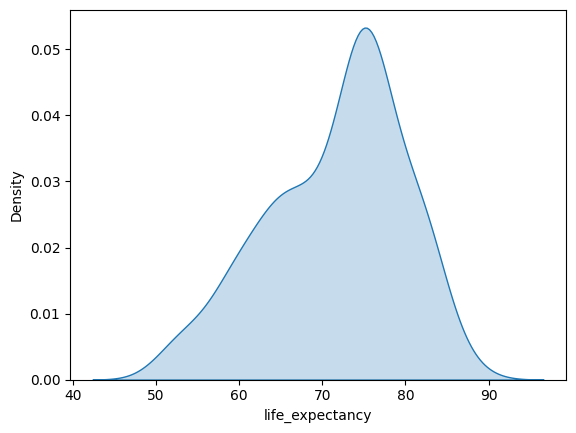

In [33]:
# KDE of dependent variable
sns.kdeplot(df2015.life_expectancy, shade=True)

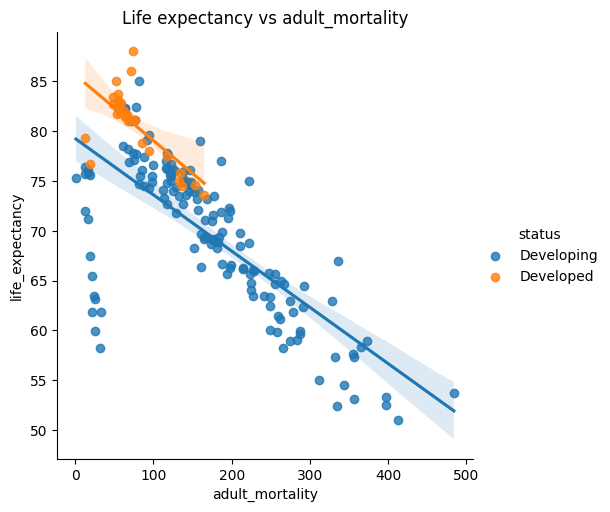

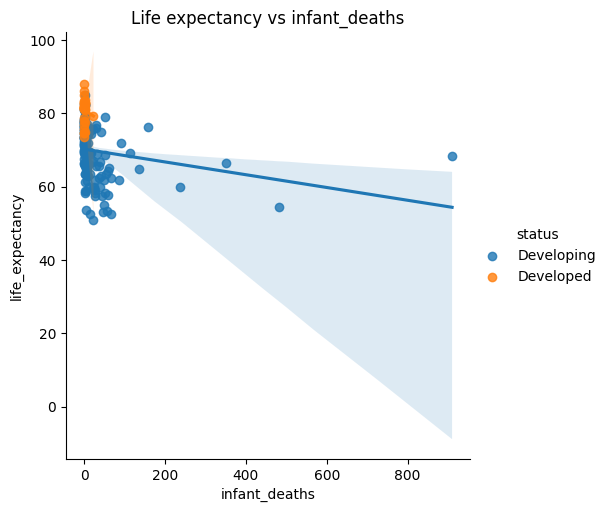

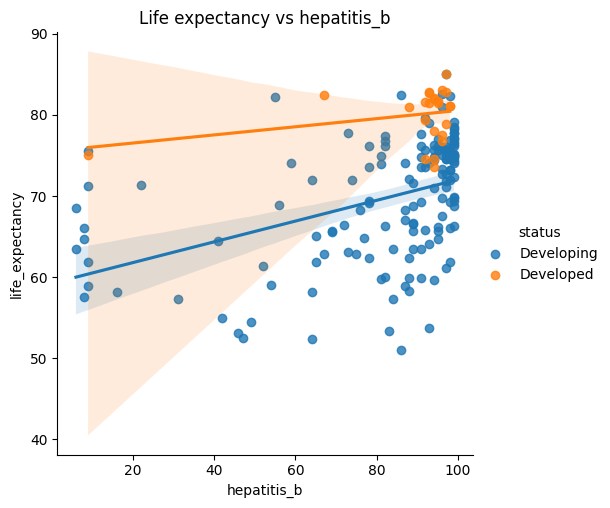

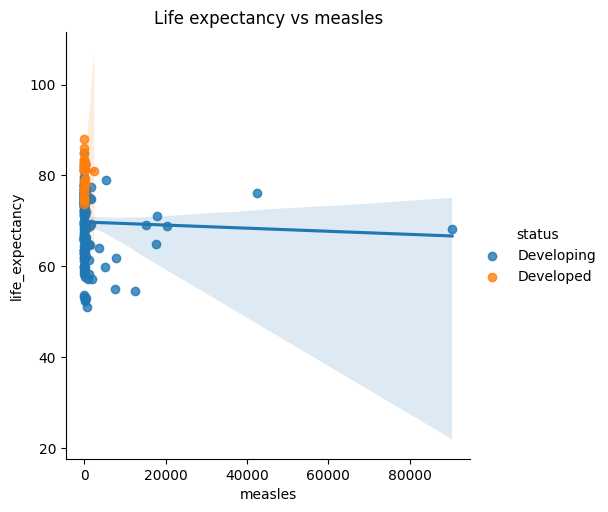

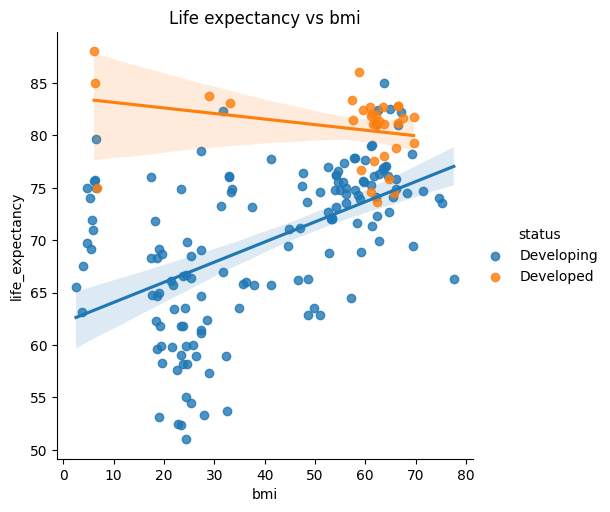

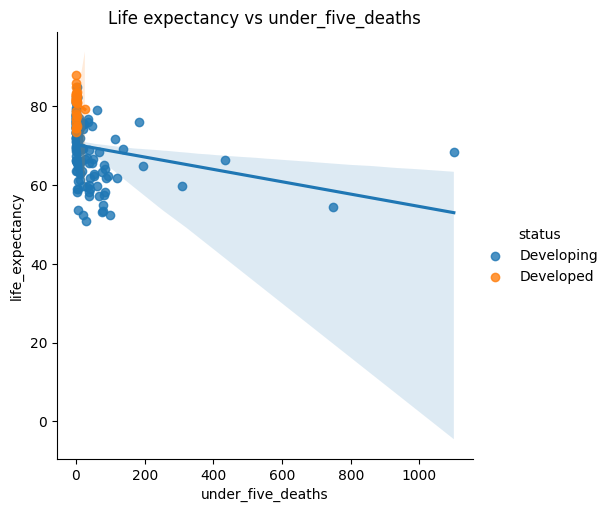

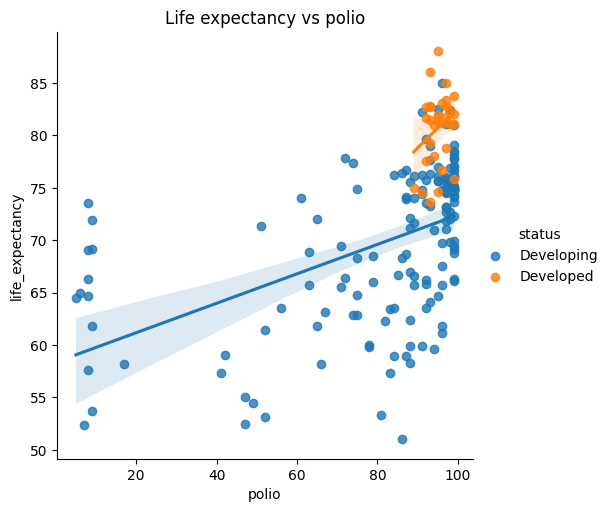

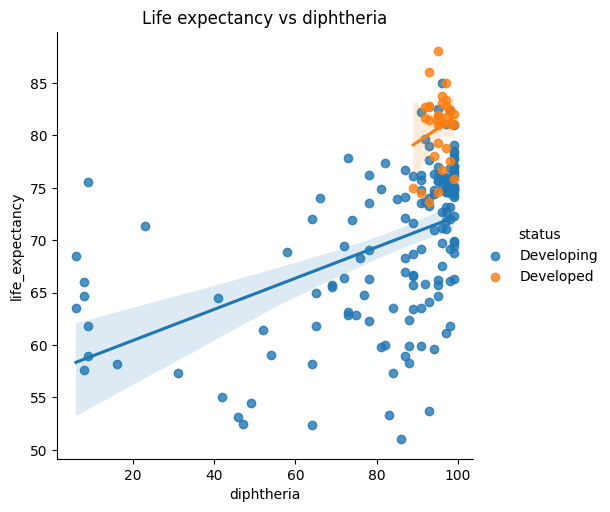

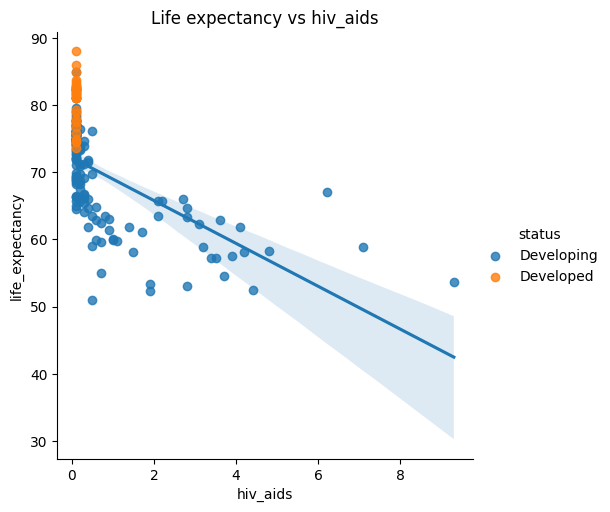

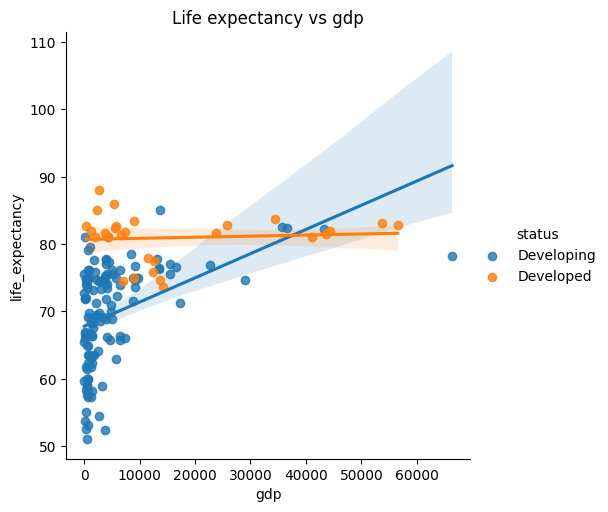

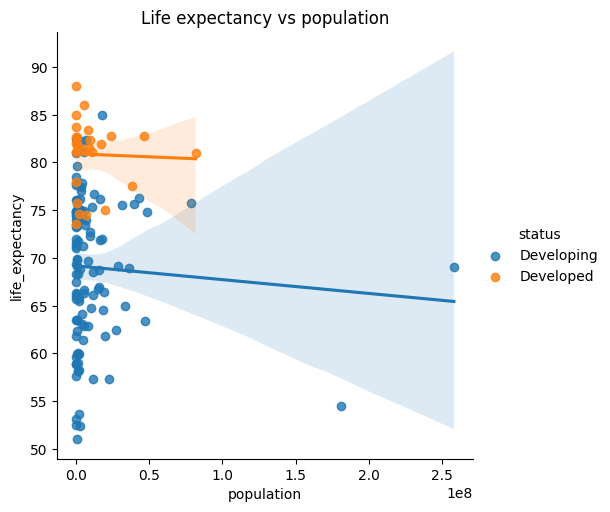

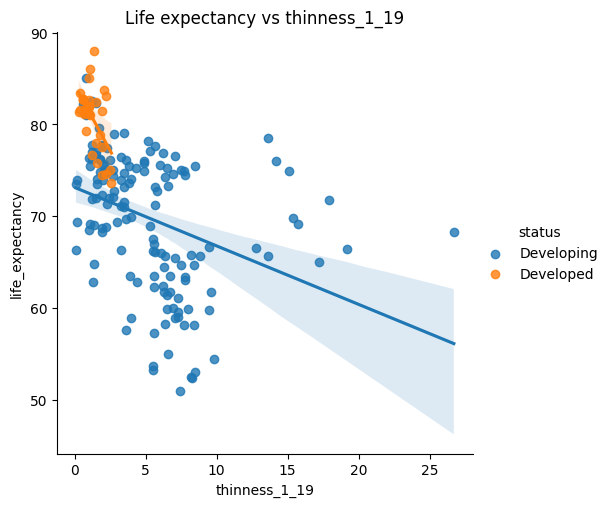

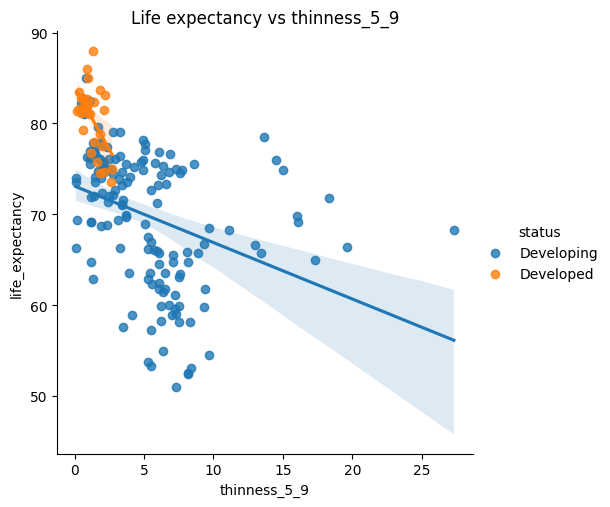

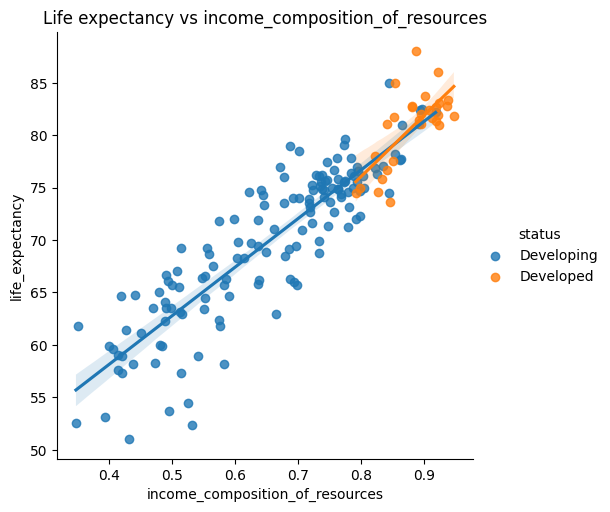

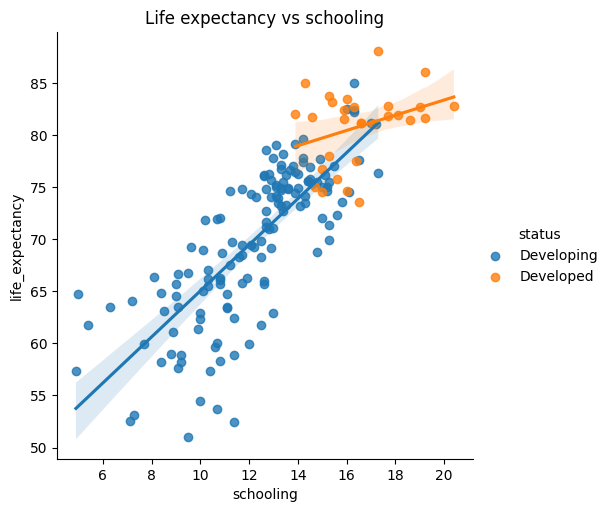

In [34]:
# Plot numeric features against target
for feature in numerics:
    sns.lmplot(x=feature, y="life_expectancy", hue="status", data=df2015)
    plt.title(f"Life expectancy vs {feature}")
    plt.show()

<Axes: xlabel='status', ylabel='life_expectancy'>

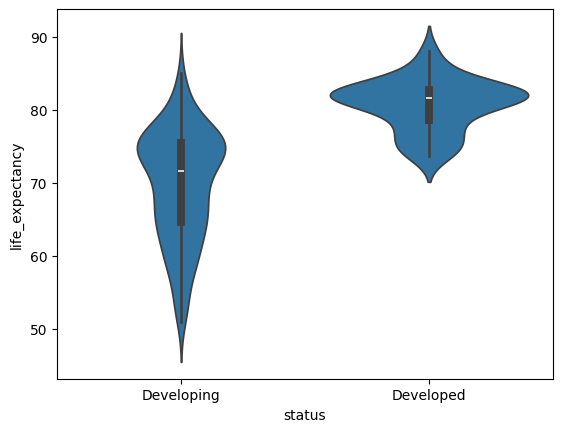

In [37]:
sns.violinplot(x="status", y="life_expectancy", data=df2015)

<Axes: >

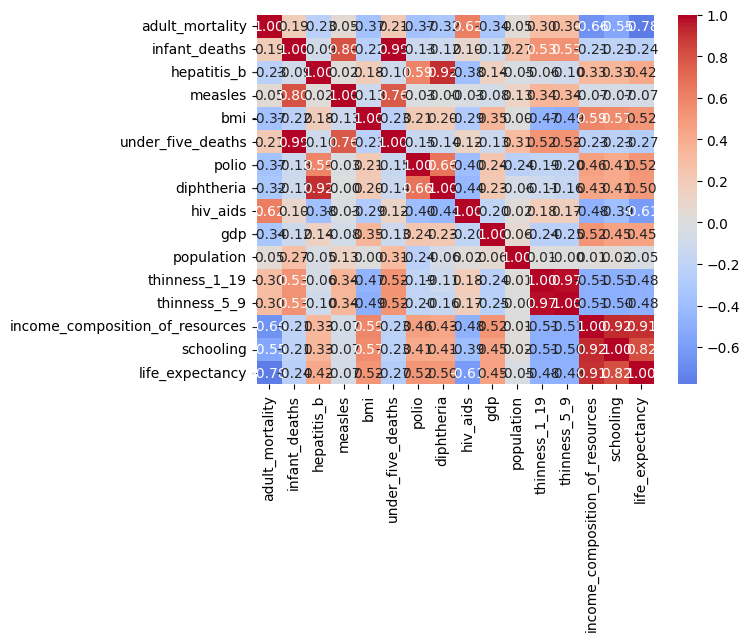

In [41]:
sns.heatmap(df2015[numerics + ["life_expectancy"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)

In [42]:
df2015 = df2015.drop(["thinness_5_9", "infant_deaths"], axis=1)

<Axes: >

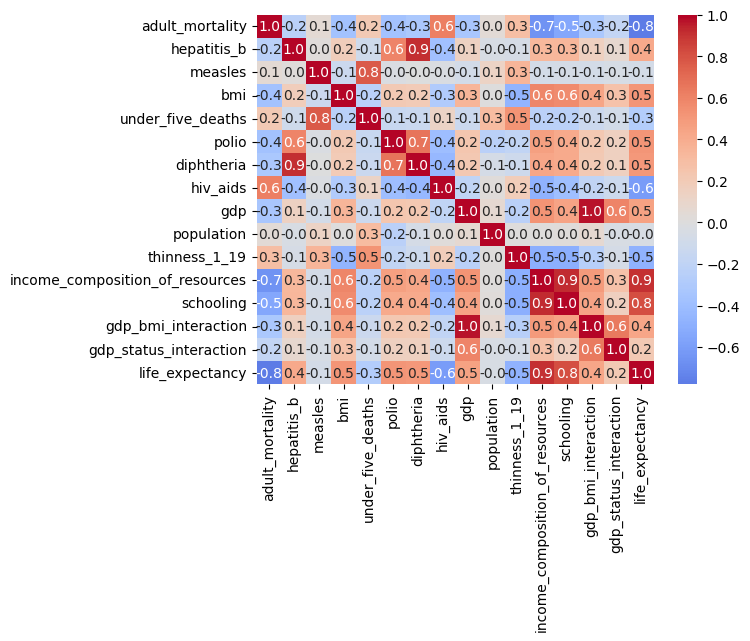

In [45]:
numerics = df2015.drop("life_expectancy", axis=1).select_dtypes("number").columns.to_list()
sns.heatmap(df2015[numerics + ["life_expectancy"]].corr(), annot=True, fmt=".1f", cmap="coolwarm", center=0)

<Axes: ylabel='Country'>

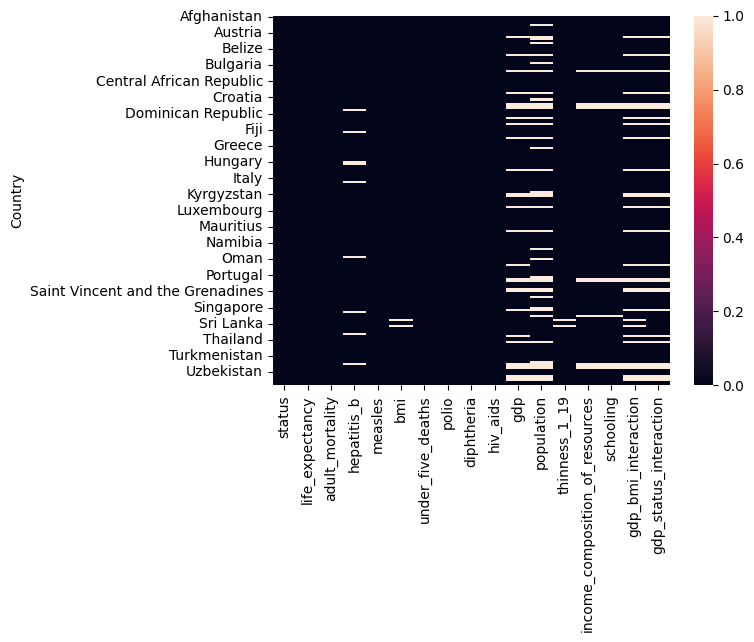

In [53]:
sns.heatmap(df2015.isna())

In [54]:
df2015["hepatitis_b"] = df2015["hepatitis_b"].fillna(df2015["hepatitis_b"].median())


In [55]:
# PCA-transform hepatitis_b, measles, polio, diphtheria, and hiv_aids
transform = ["hepatitis_b", "polio", "diphtheria"]
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
df2015["hepatitis_b_pca"] = pca.fit_transform(df2015[transform])
df2015 = df2015.drop(columns=transform)

In [56]:
df2015

,status,life_expectancy,adult_mortality,measles,bmi,under_five_deaths,hiv_aids,gdp,population,thinness_1_19,income_composition_of_resources,schooling,gdp_bmi_interaction,gdp_status_interaction,hepatitis_b_pca
Country,,,,,,,,,,,,,,,
Afghanistan,Developing,65.0,263.0,1154,19.1,83,0.1,584.259210,33736494.0,17.2,0.479,10.1,11159.350911,584.259210,-64.870998
Albania,Developing,77.8,74.0,0,58.0,0,0.1,3954.227830,28873.0,1.2,0.762,14.2,229345.214140,3954.227830,26.672641
Algeria,Developing,75.6,19.0,63,59.5,24,0.1,4132.762920,39871528.0,6.0,0.743,14.4,245899.393740,4132.762920,19.748072
Angola,Developing,52.4,335.0,118,23.3,98,1.9,3695.793748,2785935.0,8.3,0.531,11.4,86111.994328,3695.793748,-65.494181
Antigua and Barbuda,Developing,76.4,13.0,0,47.7,0,0.2,13566.954100,NaN,3.3,0.784,13.9,647143.710570,13566.954100,19.470904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela (Bolivarian Republic of),Developing,74.1,157.0,0,62.1,10,0.1,NaN,NaN,1.6,0.769,14.3,NaN,NaN,5.898935
Viet Nam,Developing,76.0,127.0,256,17.5,35,0.1,NaN,NaN,14.2,0.678,12.6,NaN,NaN,23.210356
Yemen,Developing,65.7,224.0,468,41.3,47,0.1,NaN,NaN,13.6,0.499,9.0,NaN,NaN,-28.585502


In [35]:
# Include interaction for GDP and BMI with status
df2015["gdp_bmi_interaction"] = df2015["gdp"] * df2015["bmi"]
df2015["gdp_status_interaction"] = df2015["gdp"] * df2015["status"].astype("category").cat.codes

In [79]:
# Train-test split
from sklearn.model_selection import train_test_split
X = df2015.drop(columns=["life_expectancy"])
X = sm.add_constant(X)  # Add constant for statsmodels
dummies = pd.get_dummies(X["status"], prefix="status", drop_first=True, dtype=int)
X = X.drop(columns=["status"])
X = pd.concat([X, dummies], axis=1)

y = df2015["life_expectancy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
# Impute missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
missing_cols = X.columns[X_train.isnull().any()].tolist()
X_train[missing_cols] = imputer.fit_transform(X_train[missing_cols])
X_test[missing_cols] = imputer.transform(X_test[missing_cols])


In [76]:
# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardize = X_train.select_dtypes(include=["float64", "int64"]).columns.tolist()
X_train[standardize] = scaler.fit_transform(X_train[standardize])
X_test[standardize] = scaler.transform(X_test[standardize])
X_train = sm.add_constant(X_train.drop("const", axis=1))
X_test = sm.add_constant(X_test.drop("const", axis=1))

In [90]:
# Add interactions
X_train = X_train.drop(["gdp_status_interaction", "gdp_bmi_interaction"], axis=1, errors='ignore')
X_test = X_test.drop(["gdp_status_interaction", "gdp_bmi_interaction"], axis=1, errors='ignore')
X_train["bmi_developing_interaction"] = X_train["bmi"] * X_train["status_Developing"]
X_test["bmi_developing_ interaction"] = X_test["bmi"] * X_test["status_Developing"]
X_train["gdp_developing_interaction"] = X_train["gdp"] * X_train["status_Developing"]
X_test["gdp_developing_interaction"] = X_test["gdp"] * X_test["status_Developing"]

In [83]:
X_test.isna().sum()

const                              0
adult_mortality                    0
measles                            0
bmi                                0
under_five_deaths                  0
hiv_aids                           0
gdp                                0
population                         0
thinness_1_19                      0
income_composition_of_resources    0
schooling                          0
gdp_bmi_interaction                0
gdp_status_interaction             0
hepatitis_b_pca                    0
status_Developing                  0
dtype: int64

In [87]:
X_test

,const,adult_mortality,measles,bmi,under_five_deaths,hiv_aids,gdp,population,thinness_1_19,income_composition_of_resources,schooling,gdp_bmi_interaction,gdp_status_interaction,hepatitis_b_pca,status_Developing,bmi_developing_ interaction,gdp_developing_interaction
Country,,,,,,,,,,,,,,,,,
Bolivia (Plurinational State of),1.0,186.0,0,52.6,10,0.1,3825.404795,1894575.5,1.2,0.671,13.8,130846.648109,1427.864238,26.672641,1,52.6,3825.404795
Cyprus,1.0,52.0,0,6.3,0,0.1,2375.112700,116985.0,1.0,0.854,14.3,14963.210010,0.000000,23.210356,0,0.0,0.000000
Swaziland,1.0,373.0,0,32.3,3,7.1,3136.925110,131911.0,4.0,0.541,11.4,101322.681053,3136.925110,-87.581668,1,32.3,3136.925110
Myanmar,1.0,199.0,6,23.8,50,0.3,1194.591370,5243669.0,12.8,0.552,9.1,28431.274606,1194.591370,9.361219,1,23.8,1194.591370
Solomon Islands,1.0,177.0,0,5.5,0,0.1,1922.413880,587482.0,1.1,0.514,9.6,10573.276340,1922.413880,25.495478,1,5.5,1922.413880
Belgium,1.0,74.0,47,63.7,1,0.1,4356.875000,11274196.0,1.0,0.895,16.6,277532.937500,0.000000,26.072861,0,0.0,0.000000
Bulgaria,1.0,137.0,0,65.7,1,0.1,6993.477360,7177991.0,1.9,0.792,15.0,459471.462552,0.000000,13.423283,0,0.0,0.000000
Guinea-Bissau,1.0,275.0,153,26.3,6,3.2,596.871719,177526.0,7.1,0.421,9.2,15697.726207,596.871719,5.898935,1,26.3,596.871719
Niger,1.0,22.0,7693,19.3,87,0.4,358.997310,19896965.0,9.6,0.351,5.4,6928.648083,358.997310,-32.186192,1,19.3,358.997310


# Fit linear OLS

<Axes: >

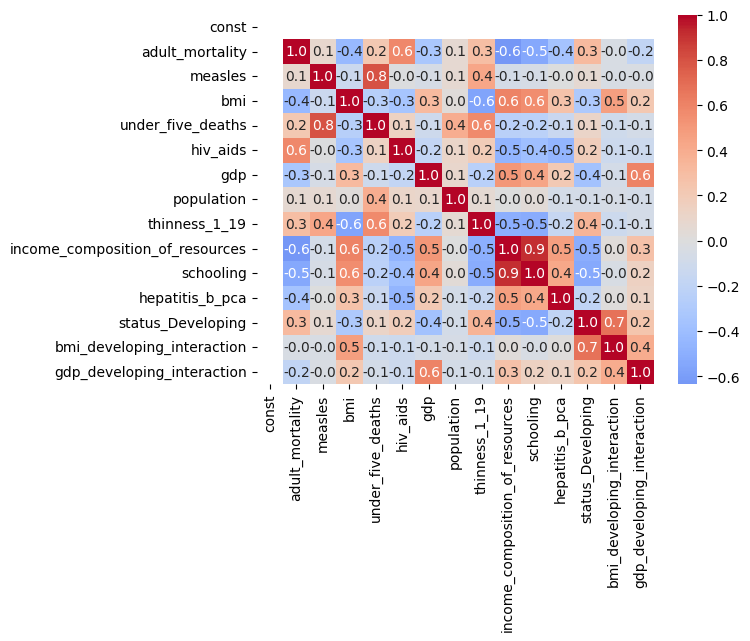

In [91]:
sns.heatmap(X_train.corr(), annot=True, fmt=".1f", cmap="coolwarm", center=0)

In [95]:
OLS = sm.OLS(y_train, X_train).fit()
print(OLS.summary())

OLS_preds = OLS.predict(X_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(f"MSE: {mean_squared_error(y_test, OLS_preds)}")
print(f"MAE: {mean_absolute_error(y_test, OLS_preds)}")
print(f"R^2: {r2_score(y_test, OLS_preds)}")

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     61.60
Date:                Tue, 29 Jul 2025   Prob (F-statistic):           1.52e-50
Time:                        19:18:24   Log-Likelihood:                -362.94
No. Observations:                 146   AIC:                             755.9
Df Residuals:                     131   BIC:                             800.6
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

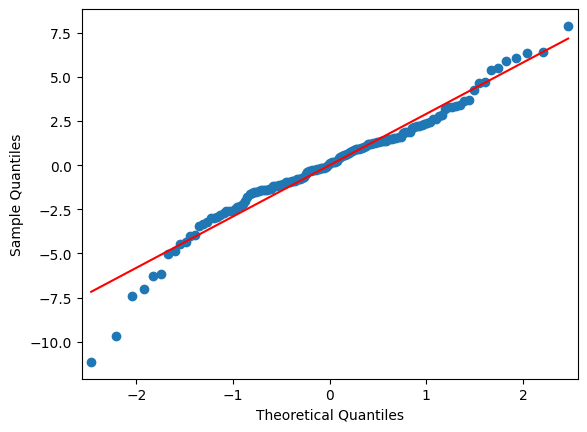

In [93]:
qq = sm.qqplot(OLS.resid, line='s')

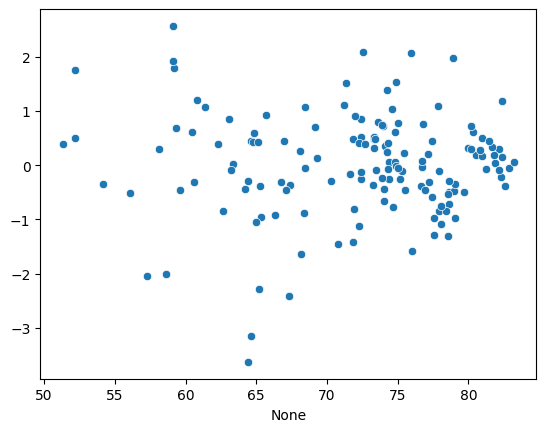

In [94]:
fitted = sns.scatterplot(x=OLS.fittedvalues, y=OLS.resid_pearson)

# Regularized OLS

In [135]:
OLS_reg = sm.OLS(y_train, X_train).fit_regularized(L1_wt=0.1, alpha=0.1, refit=True)
print(OLS_reg.summary())

OLS_reg_preds = OLS_reg.predict(X_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(f"MSE: {mean_squared_error(y_test, OLS_reg_preds)}")
print(f"MAE: {mean_absolute_error(y_test, OLS_reg_preds)}")
print(f"R^2: {r2_score(y_test, OLS_reg_preds)}")

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     61.97
Date:                Tue, 29 Jul 2025   Prob (F-statistic):           6.31e-51
Time:                        20:05:58   Log-Likelihood:                -363.05
No. Observations:                 146   AIC:                             756.1
Df Residuals:                     132   BIC:                             800.8
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [134]:
OLS_reduced = sm.OLS(y_train, X_train[["const", "bmi", "adult_mortality", "bmi_developing_interaction", "gdp_developing_interaction", "status_Developing", "gdp", "hepatitis_b_pca"]]).fit()
print(OLS_reduced.summary())

OLS_reduced_preds = OLS_reduced.predict(X_test[["const", "bmi", "adult_mortality", "bmi_developing_interaction", "gdp_developing_interaction", "status_Developing", "gdp", "hepatitis_b_pca"]])
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(f"MSE: {mean_squared_error(y_test, OLS_reduced_preds)}")
print(f"MAE: {mean_absolute_error(y_test, OLS_reduced_preds)}")
print(f"R^2: {r2_score(y_test, OLS_reduced_preds)}")

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     78.22
Date:                Tue, 29 Jul 2025   Prob (F-statistic):           6.71e-45
Time:                        20:05:37   Log-Likelihood:                -393.82
No. Observations:                 146   AIC:                             803.6
Df Residuals:                     138   BIC:                             827.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

KeyError: "['bmi_developing_interaction'] not in index"

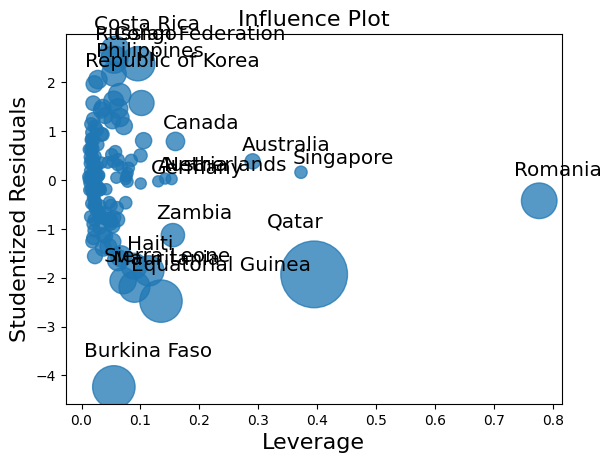

In [109]:
cooks = sm.graphics.influence_plot(OLS_reduced, criterion="cooks")

In [116]:
y_train.loc["Burkina Faso"]

np.float64(59.9)

In [115]:
OLS_reduced.fittedvalues.loc["Burkina Faso"]

np.float64(74.25414581841545)

# Removing countries with very high model impact

In [ ]:
score = OLS_reduced.get_influence().summary_frame()["cooks_d"] * OLS_reduced.get_influence().summary_frame()["hat_diag"]
score.sort_values(ascending=False, inplace=True)
score.head(5).index
X_train1 = X_train.drop(index=score.head(5).index)
y_train1 = y_train.drop(index=score.head(5).index)
OLS_reduced1 = sm.OLS(y_train1, X_train1[["const", "bmi", "adult_mortality", "bmi_developing_interaction", "gdp_developing_interaction", "status_Developing", "gdp", "hepatitis_b_pca"]]).fit()
print(OLS_reduced1.summary())


                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     96.22
Date:                Tue, 29 Jul 2025   Prob (F-statistic):           6.56e-49
Time:                        19:58:42   Log-Likelihood:                -365.32
No. Observations:                 141   AIC:                             746.6
Df Residuals:                     133   BIC:                             770.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [131]:
pd.get_dummies(df2015["status"])

,Developed,Developing
Country,,
Afghanistan,False,True
Albania,False,True
Algeria,False,True
Angola,False,True
Antigua and Barbuda,False,True
...,...,...
Venezuela (Bolivarian Republic of),False,True
Viet Nam,False,True
Yemen,False,True


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 497
[LightGBM] [Info] Number of data points in the train set: 146, number of used features: 15
[LightGBM] [Info] Start training from score 72.015753
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

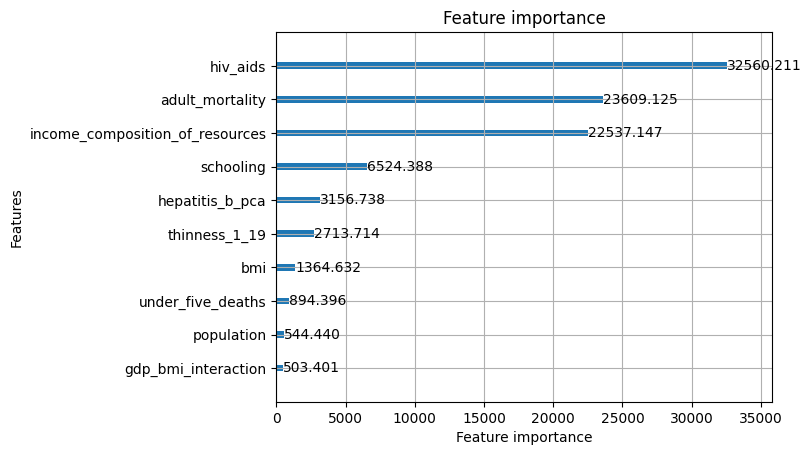

In [132]:
# Fit LightGBM model
import lightgbm as lgb
X1 = pd.concat([df2015.drop(columns=["life_expectancy", "status"]), pd.get_dummies(df2015["status"])], axis=1)
y1 = df2015["life_expectancy"]
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
lgb_train = lgb.Dataset(X_train1, label=y_train1)
lgb_test = lgb.Dataset(X_test1, label=y_test1)
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
}
lgb_model = lgb.train(params, lgb_train, num_boost_round=1000, valid_sets=[lgb_train, lgb_test])
lgb_preds = lgb_model.predict(X_test1)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(f"MSE: {mean_squared_error(y_test1, lgb_preds)}")
print(f"MAE: {mean_absolute_error(y_test1, lgb_preds)}")
print(f"R^2: {r2_score(y_test1, lgb_preds)}")
# Feature importance
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain')